## Project Introduction

The objective of this project is to classify wines into High (Premium) and Low (Normal) quality categories using machine learning models.

Beyond standard classification performance, this project focuses on a cost-sensitive evaluation, where different types of prediction errors have distinct business impacts. In particular, false positives are significantly more costly than false negatives, making the identification of these critical.

The analysis follows a structured workflow, starting with exploratory data analysis and data preparation, followed by model training, evaluation, and optimization. Finally, models are compared based on their ability to maximize profit under the defined cost structure.

## Exploratory Analisis and Data Cleaning

### Initial Data Exploration

In this section, We perform an initial inspection of the dataset to understand its structure, variable types, and basic statistical properties. This includes reviewing sample rows, checking for missing values, and analyzing summary statistics.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
data = pd.read_csv("wine_quality.csv")

In [3]:
data.head()

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
data.shape

(4648, 12)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4648 entries, 0 to 4647
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed.acidity         4648 non-null   float64
 1   volatile.acidity      4648 non-null   float64
 2   citric.acid           4648 non-null   float64
 3   residual.sugar        4648 non-null   float64
 4   chlorides             4648 non-null   float64
 5   free.sulfur.dioxide   4648 non-null   float64
 6   total.sulfur.dioxide  4648 non-null   float64
 7   density               4648 non-null   float64
 8   pH                    4648 non-null   float64
 9   sulphates             4648 non-null   float64
 10  alcohol               4648 non-null   float64
 11  quality               4648 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 435.9 KB


In [6]:
data.describe()

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
count,4648.000000,4648.000000,4648.000000,4648.000000,4648.000000,4648.000000,4648.000000,4648.000000,4648.000000,4648.000000,4648.000000,4648.000000
mean,6.857788,0.278215,0.333978,6.401366,0.045657,35.320891,138.455895,0.994035,3.188128,0.490105,10.513715,5.879948
std,0.846006,0.100574,0.120956,5.074572,0.020996,17.032638,42.596877,0.003002,0.150626,0.114484,1.231965,0.887109
min,3.800000,0.080000,0.000000,0.600000,0.012000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991720,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993800,3.180000,0.480000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996113,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.290000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


With a simple look at the dataset, it is clear that it is composed of physicochemical properties of wines, including variables such as acidity, sugar content, alcohol level, and pH.

These variables represent technical characteristics of the wine’s composition and are commonly used to assess its quality. Changes in these properties can significantly influence taste, balance, and overall perception, making them relevant predictors for identifying high-quality wines.

In [7]:
colors = ['#FC8D62','#66C2A5']

colors_seq = [
    "#fee6ce",
    "#fdd0a2",
    "#fdae6b",
    "#fd8d3c",
    "#f16913",
    "#d94801",
    "#a63603",
    "#7f2704"
]

### Target Variable Distribution

We analyze the distribution of the wine quality variable to understand how samples are distributed across different quality levels. This step is key to identifying potential class imbalance, which can significantly impact model performance and evaluation.

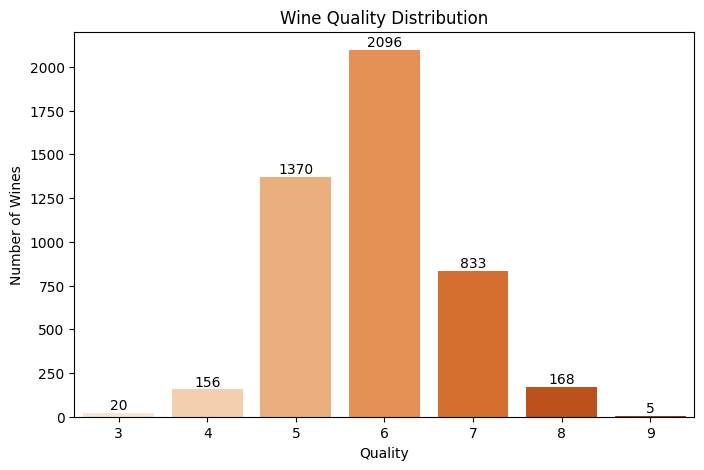

In [ ]:
counts = data['quality'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=counts.index, y=counts.values, palette="Oranges")

for i, v in enumerate(counts.values):
    plt.text(i, v + 20, str(v), ha='center')

plt.title("Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Number of Wines")

plt.show()

The distribution is highly concentrated around mid-quality values (5 and 6), with significantly fewer observations in the extreme categories. This indicates a clear class imbalance, which will be especially relevant when transforming the problem into a binary classification task (Low vs High quality).

### Feature Relationships

We analyze the correlation between variables to identify relationships, potential multicollinearity, and features that may be relevant for predicting wine quality.

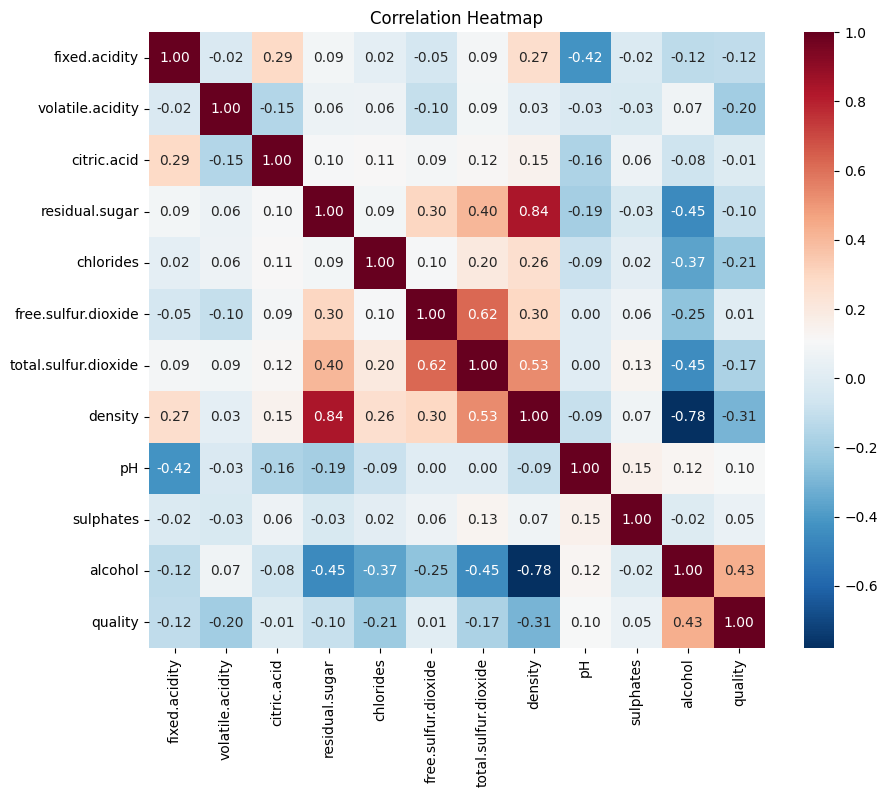

In [9]:
corr = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', square=True)
plt.title('Correlation Heatmap')
plt.show()

The heatmap shows moderate correlations between some variables. In particular, alcohol has the strongest positive relationship with quality, while density shows a notable negative correlation. 

Additionally, there are strong correlations between some features, such as residual sugar and density, and between free sulfur dioxide and total sulfur dioxide, which may indicate multicollinearity.

These relationships will be important when selecting and evaluating models, especially for linear methods such as Logistic Regression.

### Relationship Between Key Variables

We explore the relationships of Density vs Alcohol and Density vs Residual Sugar, as they show a strong correlation and potential presence of extreme values.

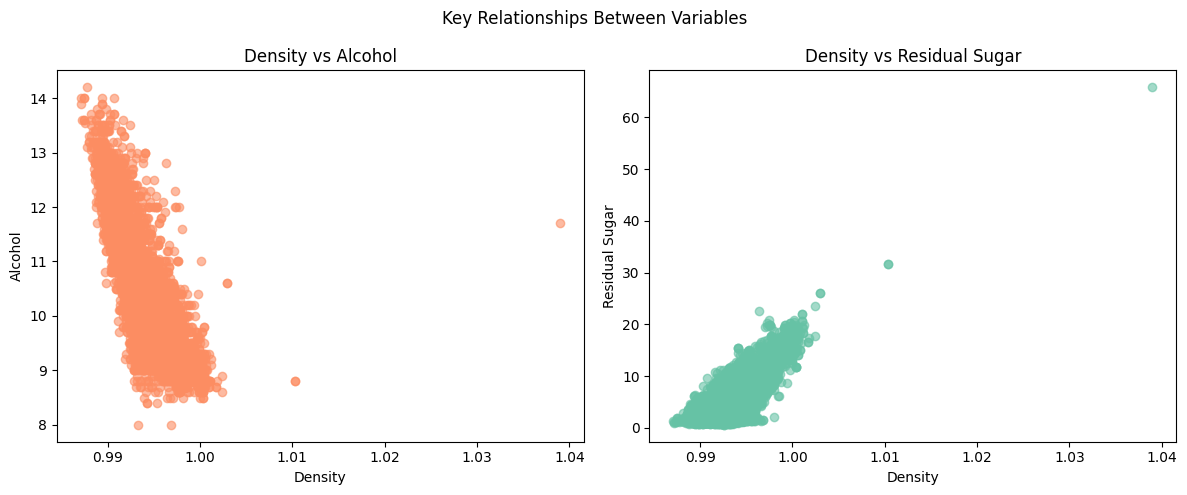

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Alcohol vs Density
axes[0].scatter(data['density'], data['alcohol'], color='#FC8D62', alpha=0.6)
axes[0].set_xlabel('Density')
axes[0].set_ylabel('Alcohol')
axes[0].set_title('Density vs Alcohol')

# Density vs Residual Sugar
axes[1].scatter(data['density'], data['residual.sugar'], color='#66C2A5', alpha=0.6)
axes[1].set_xlabel('Density')
axes[1].set_ylabel('Residual Sugar')
axes[1].set_title('Density vs Residual Sugar')

plt.suptitle('Key Relationships Between Variables')
plt.tight_layout()
plt.show()

The scatter plots reveal clear relationships between key variables. Alcohol shows a strong negative association with density, while density presents a strong positive relationship with residual sugar.

In both cases, a small number of extreme observations can be identified, which may distort these relationships and impact model performance.

These findings reinforce the need for applying outlier treatment in the next steps.

### Outlier Detection

We begin by analyzing the distribution of all variables using boxplots to detect extreme values that may impact model performance. From this analysis, a subset of variables is selected for visualization.

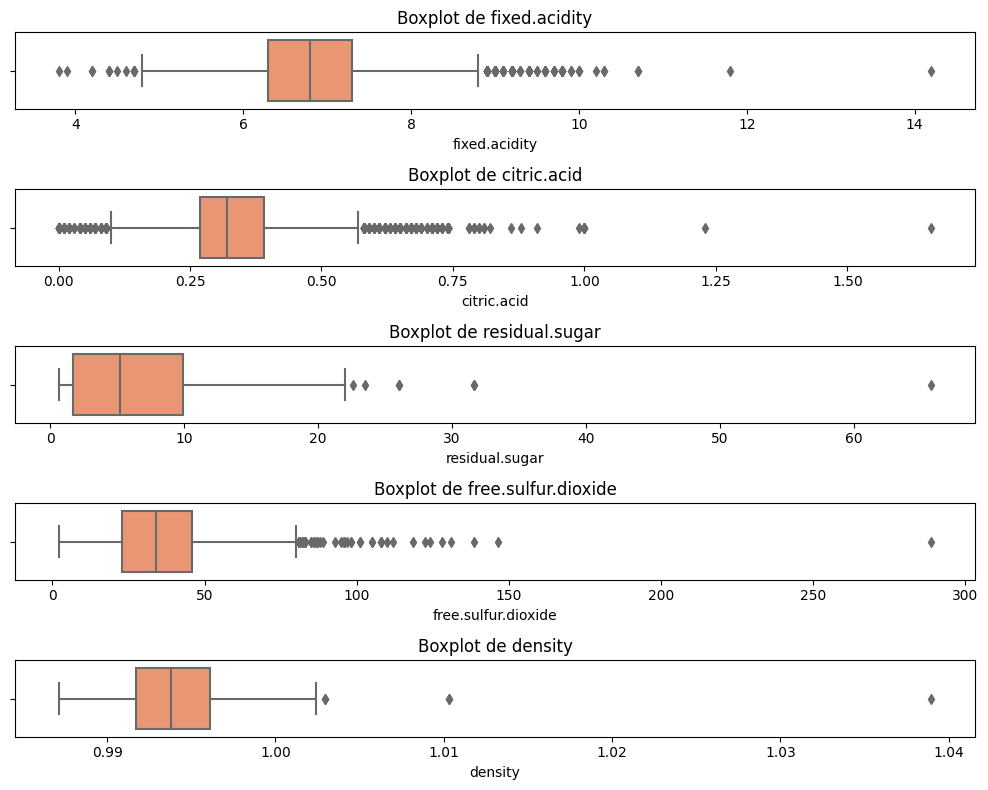

In [11]:
cols = ["fixed.acidity", "citric.acid", "residual.sugar", "free.sulfur.dioxide", "density"]
fig, axes = plt.subplots(nrows=len(cols), figsize=(10, 8), sharex=False)

for ax, col in zip(axes, cols):
    sns.boxplot(x=data[col], orient="h", ax=ax, color='#FC8D62')
    ax.set_title(f"Boxplot de {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

Several variables present significant outliers, particularly residual sugar, free sulfur dioxide, and citric acid. These extreme values may distort statistical relationships and negatively impact certain models, especially those sensitive to scale and distribution.

Therefore, outlier treatment will be applied to improve data stability while preserving the overall structure of the dataset.

### Outlier Treatment

Outliers were handled through controlled filtering by applying upper thresholds to selected variables. These thresholds were defined based on prior visual analysis (boxplots and scatter plots), focusing only on extreme values that clearly fall outside the typical data distribution.

This approach was chosen to remove the most influential extreme observations while preserving the overall structure of the dataset. More aggressive methods such as clipping were not applied in order to avoid altering the original data distribution.

By applying targeted filtering instead of global transformations, we ensure a balance between reducing noise and maintaining data integrity.

In [12]:
data = data[data["fixed.acidity"] < 11]
data = data[data["citric.acid"] < 1.10]
data = data[data["residual.sugar"] < 40]
data = data[data["free.sulfur.dioxide"] < 150]
data = data[data["density"] < 1.009]

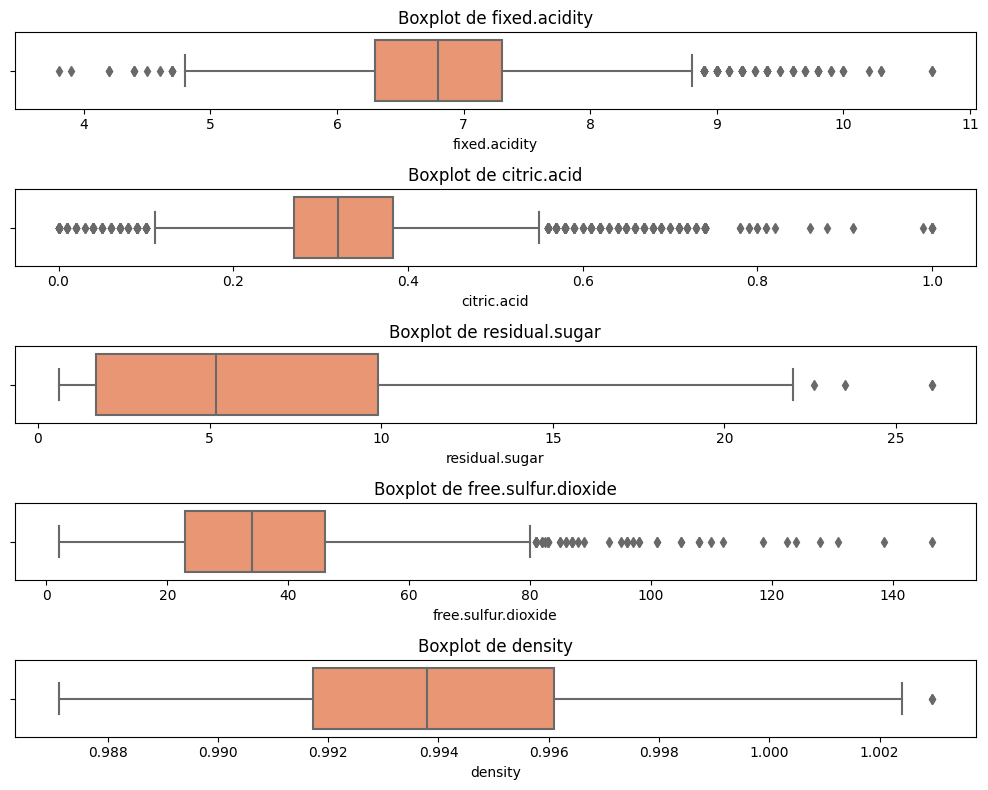

In [13]:
cols = ["fixed.acidity", "citric.acid", "residual.sugar", "free.sulfur.dioxide", "density"]

fig, axes = plt.subplots(nrows=len(cols), figsize=(10, 8), sharex=False)

for ax, col in zip(axes, cols):
    sns.boxplot(x=data[col], orient="h", ax=ax, color='#FC8D62')
    ax.set_title(f"Boxplot de {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

After applying the filtering thresholds, the distributions show a noticeable reduction in extreme values while maintaining their overall shape. 

This confirms that the treatment effectively reduces the impact of outliers without significantly distorting the underlying data.

We visualize the same relationships after applying outlier filtering to evaluate how the treatment affects the data distribution and variable interactions.

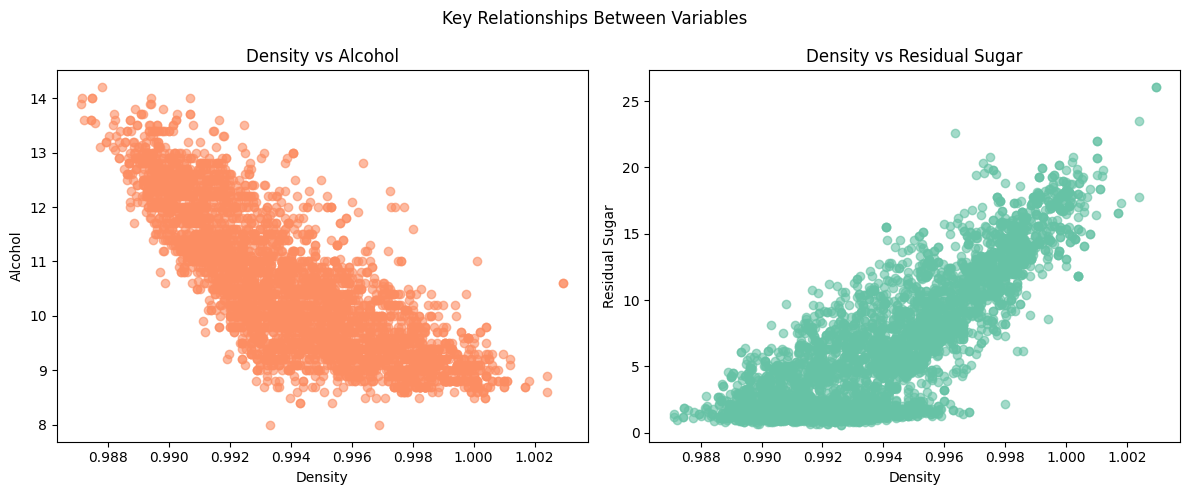

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(data['density'], data['alcohol'], color='#FC8D62', alpha=0.6)
axes[0].set_xlabel('Density')
axes[0].set_ylabel('Alcohol')
axes[0].set_title('Density vs Alcohol')

axes[1].scatter(data['density'], data['residual.sugar'], color='#66C2A5', alpha=0.6)
axes[1].set_xlabel('Density')
axes[1].set_ylabel('Residual Sugar')
axes[1].set_title('Density vs Residual Sugar')

plt.suptitle('Key Relationships Between Variables')
plt.tight_layout()
plt.show()

After removing extreme values, the relationships between variables appear significantly more consistent and less affected by dispersion. 

The overall structure of the data is preserved, while the influence of extreme observations is reduced, leading to clearer patterns and more reliable relationships.

This improvement supports the effectiveness of the applied outlier treatment.

### Feature Transformation

During exploratory analysis, some variables such as chlorides and residual sugar showed highly skewed distributions, with long right tails and the presence of extreme values.

Additionally, pairwise visualizations suggested non-linear relationships between these features and other variables.

To reduce skewness and stabilize variance, a logarithmic transformation was applied to these variables.

To better understand the impact of the transformation, the relationship between residual sugar and density is visualized before and after applying the logarithmic transformation.

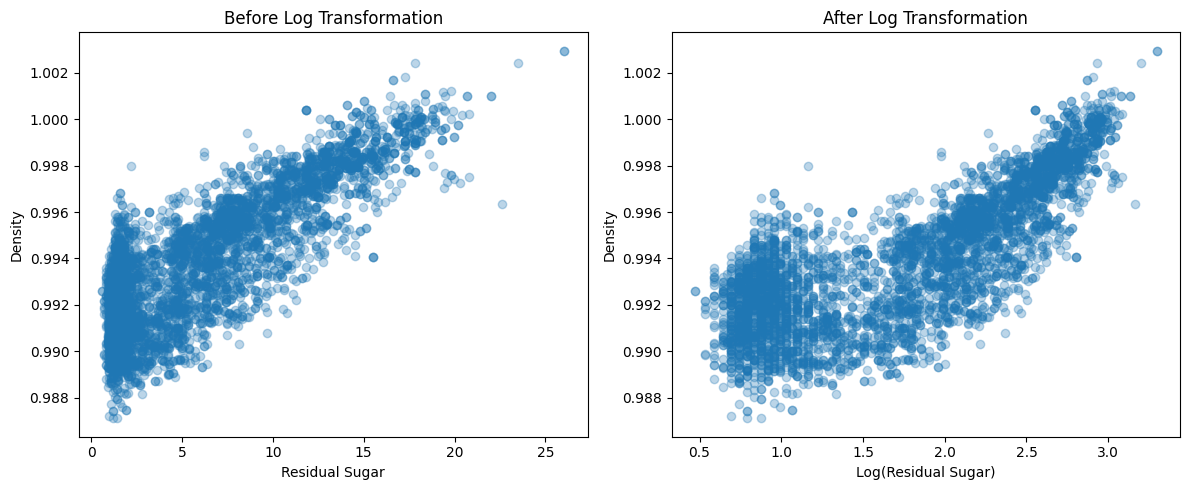

In [ ]:
original = data['residual.sugar']
log_transformed = np.log1p(original)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(original, data['density'], alpha=0.3)
axes[0].set_title('Before Log Transformation')
axes[0].set_xlabel('Residual Sugar')
axes[0].set_ylabel('Density')

axes[1].scatter(log_transformed, data['density'], alpha=0.3)
axes[1].set_title('After Log Transformation')
axes[1].set_xlabel('Log(Residual Sugar)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

The logarithmic transformation reduces the concentration of extreme values and leads to a more balanced distribution of the feature. While the relationship does not become strictly linear, the transformed feature exhibits a more stable structure, which can improve model performance.

It is particularly beneficial for models such as Logistic Regression, which are sensitive to feature distribution and scale.

In [ ]:
data["chlorides"] = np.log1p(data["chlorides"])

In addition, a new feature was created by combining alcohol and density, as these variables showed a strong relationship. The ratio between them aims to capture their joint effect in a single feature, potentially improving model performance.

In [148]:
data["alcohol.density.ratio"] = data["alcohol"] / data["density"]

### Feature Correlation with Target

We analyze the correlation between each feature and wine quality to understand which variables are more strongly associated with the target.

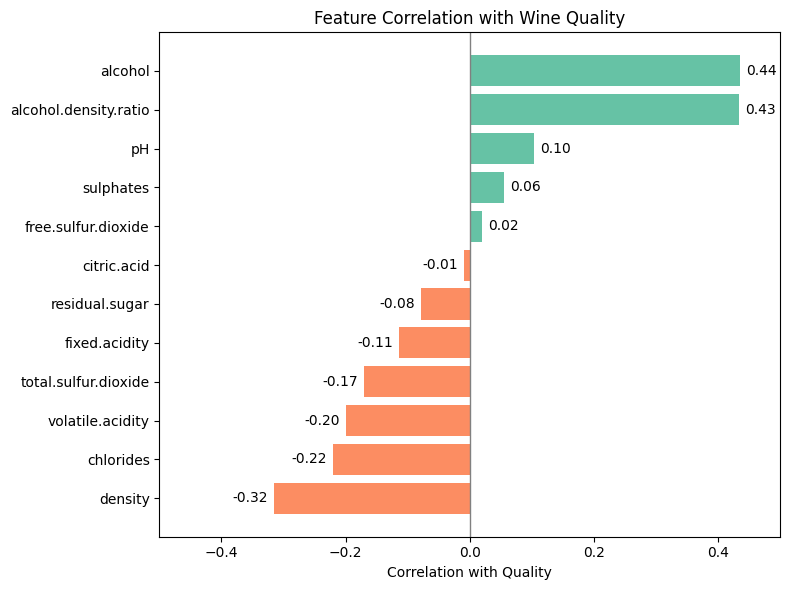

In [ ]:
corr = data.corr(numeric_only=True)['quality'].drop('quality')
corr = corr.sort_values()

colors_mpl = ['#FC8D62' if x < 0 else '#66C2A5' for x in corr.values]

plt.figure(figsize=(8,6))

bars = plt.barh(corr.index, corr.values, color=colors_mpl)

plt.axvline(0, color='gray', linewidth=1)

for i, v in enumerate(corr.values):
    plt.text(
        v + (0.01 if v >= 0 else -0.01),
        i,
        f"{v:.2f}",
        va='center',
        ha='left' if v >= 0 else 'right'
    )

plt.title('Feature Correlation with Wine Quality')
plt.xlabel('Correlation with Quality')
plt.ylabel('')

plt.xlim(-0.5, 0.5)

plt.tight_layout()
plt.show()

The results show that alcohol has the strongest positive relationship with wine quality, followed closely by the engineered feature alcohol-density ratio. This suggests that higher alcohol content is associated with higher quality wines.

On the other hand, variables such as density, chlorides, and volatile acidity present negative correlations with quality. It is important to note that a negative correlation does not imply a worse feature; it simply indicates an inverse relationship with the target.

In this context, lower values of these variables are associated with higher quality wines, making them equally relevant for predictive modeling.

Overall, these relationships provide useful insights into which features may contribute more significantly to the model's predictions.

These findings will help guide the modeling process and reinforce the importance of considering both positively and negatively correlated features.

### Target Variable Definition

To transform the problem into a binary classification task, the original quality variable is converted into two categories: High and Low quality wines.

Wines with a quality score greater than 6 are labeled as High, while the rest are classified as Low.

In [ ]:
data['quality_label'] = np.where(data['quality'] > 6, 'High', 'Low')

data[['quality', 'quality_label']].head()

,quality,quality_label
0,6,Low
1,6,Low
2,6,Low
3,6,Low
4,6,Low


In [151]:
data['quality_label'].value_counts()

quality_label
Low     3634
High    1006
Name: count, dtype: int64

c:\Users\Manue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:641: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



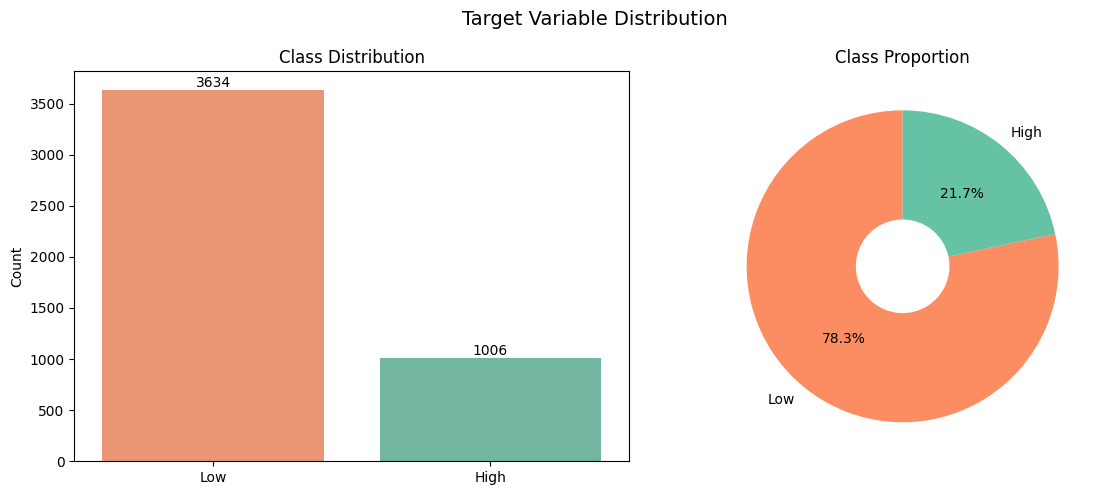

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = data['quality_label'].value_counts().reset_index()
counts.columns = ['quality_label', 'count']

counts['quality_label'] = pd.Categorical(
    counts['quality_label'],
    categories=['Low', 'High'],
    ordered=True
)
counts = counts.sort_values('quality_label')

bar_colors = [colors[0], colors[1]]
pie_colors = [colors[0], colors[1]]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
sns.barplot(
    data=counts,
    x='quality_label',
    y='count',
    palette=bar_colors,
    ax=axes[0]
)

axes[0].set_title('Class Distribution')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')

for i, v in enumerate(counts['count']):
    axes[0].text(i, v + 30, f'{v}', ha='center')

# Donut chart
axes[1].pie(
    counts['count'],
    labels=counts['quality_label'],
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.7)
)
axes[1].set_title('Class Proportion')

plt.suptitle('Target Variable Distribution', fontsize=14)
plt.tight_layout()
plt.show()

The resulting distribution shows a clear class imbalance, with a significantly higher number of Low quality wines compared to High quality ones.

This imbalance will be an important factor to consider during model training and evaluation, as standard metrics such as accuracy may not be sufficient to properly assess model performance.

This reinforces the need to focus on alternative evaluation metrics and threshold optimization, especially given the business impact associated with different types of classification errors.

In [ ]:
data.to_csv("wine_clean_data.csv", index=False)

### Summary

The exploratory analysis and preprocessing steps allowed us to better understand the data, identify key relationships, and prepare the dataset for modeling.

Key actions included handling outliers, transforming skewed variables, and defining a binary target variable aligned with the business objective.